[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/harshuljain13/llm-inference-at-scale/blob/master/content/01_gpu_hardware/01.2_roofline_model/lab.ipynb)
[![Open In Molab](https://img.shields.io/badge/Open%20in-Molab-blue)](https://molab.marimo.io/github/harshuljain13/llm-inference-at-scale/blob/master/content/01_gpu_hardware/01.2_roofline_model/lab.ipynb)

# Lab 1.2: The Roofline Model

Build and interpret a GPU roofline model. Plot where LLM prefill and decode land.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# GPU specifications: peak FP16 TFLOPS and memory bandwidth (GB/s)
GPU_SPECS = {
    'T4':   {'compute_tflops': 65,  'bandwidth_gbs': 300},
    'A10G': {'compute_tflops': 125, 'bandwidth_gbs': 600},
    'A100': {'compute_tflops': 312, 'bandwidth_gbs': 2039},
    'H100': {'compute_tflops': 990, 'bandwidth_gbs': 3350},
    'B200': {'compute_tflops': 2250,'bandwidth_gbs': 8000},
}

# Ridge point = compute / bandwidth (the crossover arithmetic intensity)
for name, spec in GPU_SPECS.items():
    ridge = spec['compute_tflops'] * 1e3 / spec['bandwidth_gbs']  # FLOPS/byte
    print(f"{name}: ridge point = {ridge:.1f} FLOPS/byte")

T4: ridge point = 216.7 FLOPS/byte
A10G: ridge point = 208.3 FLOPS/byte
A100: ridge point = 153.0 FLOPS/byte
H100: ridge point = 295.5 FLOPS/byte
B200: ridge point = 281.2 FLOPS/byte


## Exercise 1: Plot the Roofline for A100

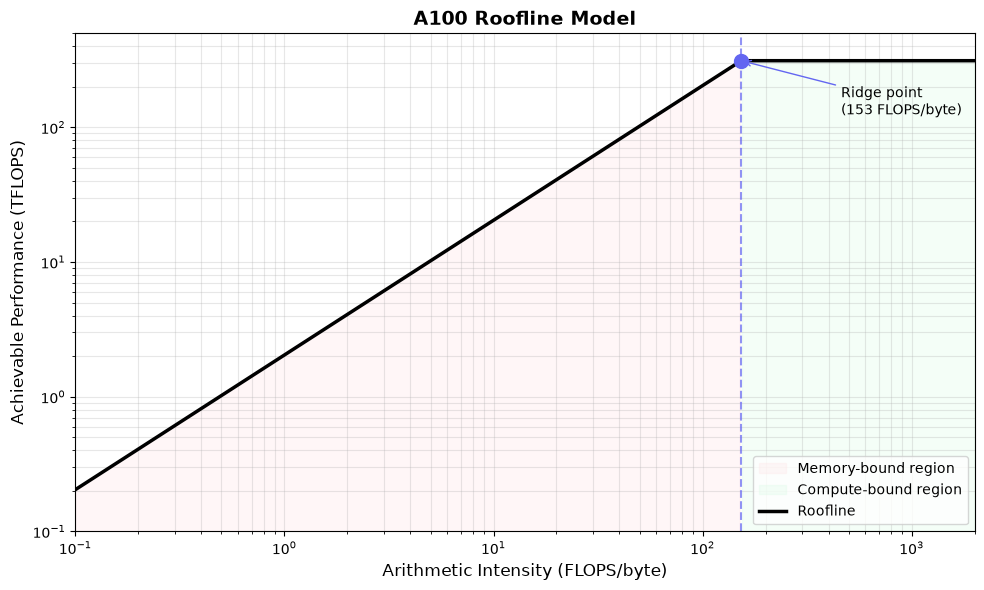

In [5]:
# --- A100 Roofline Model (log-log) ---
gpu = GPU_SPECS['A100']
peak_tflops = gpu['compute_tflops']          # Peak compute (TFLOPS)
bw_gbs = gpu['bandwidth_gbs']                # Memory bandwidth (GB/s)

# Ridge point: where bandwidth ceiling meets compute ceiling
# Units: (TFLOPS * 1e12) / (GB/s * 1e9) = FLOPS/byte
ridge_point = (peak_tflops * 1e3) / bw_gbs   # FLOPS/byte

# Arithmetic intensity range (FLOPS/byte, log scale)
ai = np.logspace(-1, 3.3, 500)  # 0.1 to 2000

# Bandwidth ceiling: achievable TFLOPS = AI * bandwidth
bw_ceiling = ai * bw_gbs / 1e3  # Convert to TFLOPS

# Achievable performance: min(bandwidth ceiling, compute ceiling)
achievable = np.minimum(bw_ceiling, peak_tflops)

fig, ax = plt.subplots(figsize=(10, 6))

# Fill memory-bound region (left of ridge) in rose
mem_mask = ai <= ridge_point
ax.fill_between(ai[mem_mask], 0.01, achievable[mem_mask],
                alpha=0.3, color='#ffe4e6', label='Memory-bound region')

# Fill compute-bound region (right of ridge) in green
comp_mask = ai >= ridge_point
ax.fill_between(ai[comp_mask], 0.01, achievable[comp_mask],
                alpha=0.3, color='#dcfce7', label='Compute-bound region')

# Plot the roofline itself
ax.loglog(ai, achievable, 'k-', linewidth=2.5, label='Roofline')

# Mark the ridge point
ax.axvline(ridge_point, color='#6366f1', linestyle='--', alpha=0.7)
ax.plot(ridge_point, peak_tflops, 'o', color='#6366f1', markersize=10)
ax.annotate(f'Ridge point\n({ridge_point:.0f} FLOPS/byte)',
            xy=(ridge_point, peak_tflops),
            xytext=(ridge_point * 3, peak_tflops * 0.4),
            fontsize=10, ha='left',
            arrowprops=dict(arrowstyle='->', color='#6366f1'))

ax.set_xlabel('Arithmetic Intensity (FLOPS/byte)', fontsize=12)
ax.set_ylabel('Achievable Performance (TFLOPS)', fontsize=12)
ax.set_title('A100 Roofline Model', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim(0.1, 2000)
ax.set_ylim(0.1, 500)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## Exercise 2: Where Does LLM Decode Land?

Decode AI (batch=1): 1.0 FLOPS/byte
A100 ridge point:    153 FLOPS/byte
Decode is 153x below the ridge point!


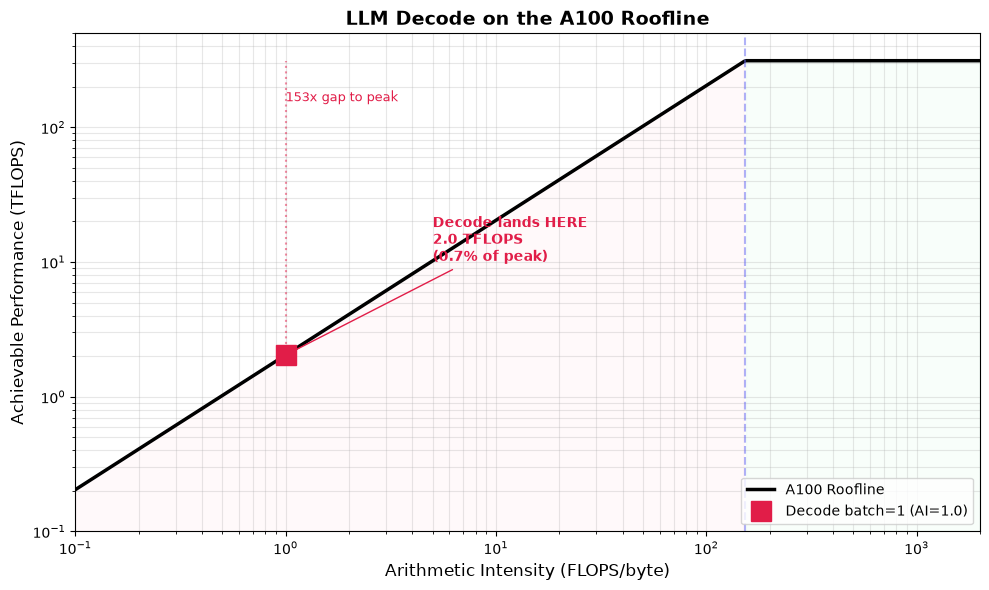

In [6]:
# --- LLM Decode: Arithmetic Intensity Analysis ---
# During decode (batch=1), each token requires reading ALL model weights
# but performs very few FLOPs per weight (just one token's matmul).

model_params = 7e9            # 7B parameter model (e.g., Llama-2-7B)
bytes_per_param = 2           # FP16 = 2 bytes per parameter
model_size_bytes = model_params * bytes_per_param  # ~14 GB

# FLOPs for one token: ~2 * params (one matmul per weight)
flops_per_token = 2 * model_params  # ~14 GFLOPS

# Arithmetic intensity for decode batch=1:
# AI = FLOPs / Bytes loaded = 2*params / (params * 2) = 1 FLOP/byte
decode_ai = flops_per_token / model_size_bytes
print(f"Decode AI (batch=1): {decode_ai:.1f} FLOPS/byte")
print(f"A100 ridge point:    {ridge_point:.0f} FLOPS/byte")
print(f"Decode is {ridge_point/decode_ai:.0f}x below the ridge point!")

# Achievable performance at this AI
decode_perf = min(decode_ai * bw_gbs / 1e3, peak_tflops)

# Plot decode on the roofline
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(ai, achievable, 'k-', linewidth=2.5, label='A100 Roofline')
ax.fill_between(ai[mem_mask], 0.01, achievable[mem_mask],
                alpha=0.2, color='#ffe4e6')
ax.fill_between(ai[comp_mask], 0.01, achievable[comp_mask],
                alpha=0.2, color='#dcfce7')

# Plot the decode operating point
ax.plot(decode_ai, decode_perf, 's', color='#e11d48', markersize=14,
        zorder=5, label=f'Decode batch=1 (AI={decode_ai:.1f})')

# Annotate how far below peak
ax.annotate(f'Decode lands HERE\n{decode_perf:.1f} TFLOPS\n'
            f'({decode_perf/peak_tflops*100:.1f}% of peak)',
            xy=(decode_ai, decode_perf),
            xytext=(decode_ai * 5, decode_perf * 5),
            fontsize=10, color='#e11d48', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#e11d48'))

# Show the gap to compute ceiling
ax.vlines(decode_ai, decode_perf, peak_tflops, colors='#e11d48',
          linestyles=':', alpha=0.5)
ax.annotate(f'{peak_tflops/decode_perf:.0f}x gap to peak',
            xy=(decode_ai, peak_tflops * 0.5), fontsize=9, color='#e11d48')

ax.axvline(ridge_point, color='#6366f1', linestyle='--', alpha=0.5)
ax.set_xlabel('Arithmetic Intensity (FLOPS/byte)', fontsize=12)
ax.set_ylabel('Achievable Performance (TFLOPS)', fontsize=12)
ax.set_title('LLM Decode on the A100 Roofline', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim(0.1, 2000)
ax.set_ylim(0.1, 500)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## Exercise 3: How Batching Moves You Up

Ridge point: 153 FLOPS/byte
Batch size to cross ridge: ~256


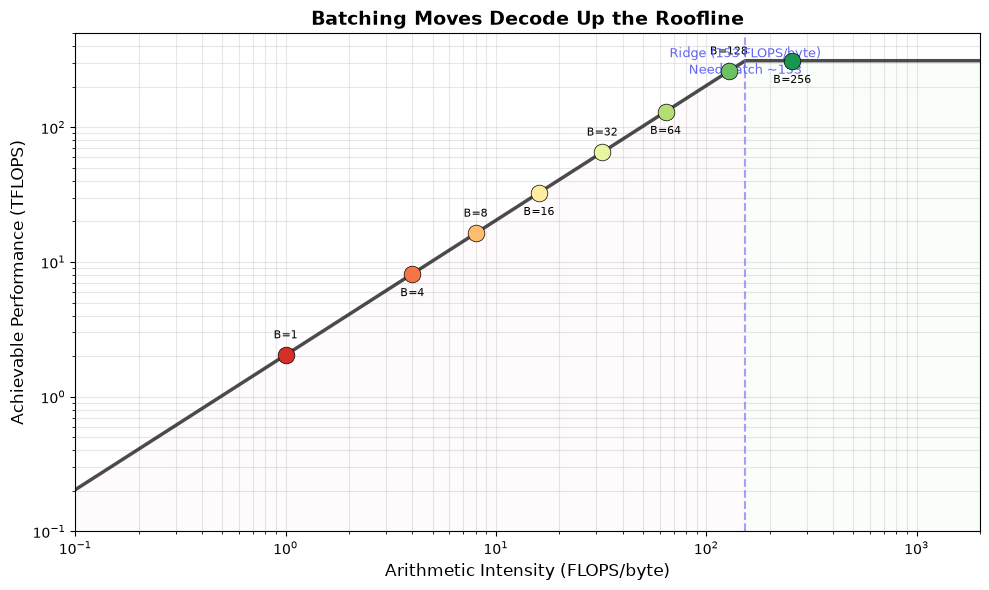

In [7]:
# --- Batching increases arithmetic intensity ---
# With batch size B, you amortize the weight reads across B tokens:
# AI = (2 * params * B) / (params * 2) = B FLOPS/byte

batch_sizes = np.array([1, 4, 8, 16, 32, 64, 128, 256])

# AI scales linearly with batch size (weights read once, used B times)
batch_ai = batch_sizes * decode_ai  # Each batch multiplies the base AI

# Achievable TFLOPS at each batch size
batch_perf = np.minimum(batch_ai * bw_gbs / 1e3, peak_tflops)

# Find which batch size crosses the ridge point
crossover_idx = np.searchsorted(batch_ai, ridge_point)
print(f"Ridge point: {ridge_point:.0f} FLOPS/byte")
print(f"Batch size to cross ridge: ~{batch_sizes[min(crossover_idx, len(batch_sizes)-1)]}")

# Color gradient: red (memory-bound) to green (compute-bound)
colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(batch_sizes)))

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(ai, achievable, 'k-', linewidth=2.5, alpha=0.7, label='Roofline')
ax.fill_between(ai[mem_mask], 0.01, achievable[mem_mask],
                alpha=0.15, color='#ffe4e6')
ax.fill_between(ai[comp_mask], 0.01, achievable[comp_mask],
                alpha=0.15, color='#dcfce7')

# Plot each batch size as a dot with color gradient
for i, (b, x, y) in enumerate(zip(batch_sizes, batch_ai, batch_perf)):
    ax.plot(x, y, 'o', color=colors[i], markersize=12, zorder=5,
            markeredgecolor='black', markeredgewidth=0.5)
    # Label each dot with batch size
    offset = (0, 12) if i % 2 == 0 else (0, -16)
    ax.annotate(f'B={b}', xy=(x, y), xytext=offset,
                textcoords='offset points', fontsize=8, ha='center')

# Mark the ridge crossover
ax.axvline(ridge_point, color='#6366f1', linestyle='--', alpha=0.6)
ax.annotate(f'Ridge ({ridge_point:.0f} FLOPS/byte)\n'
            f'Need batch ~{int(ridge_point)}'  ,
            xy=(ridge_point, peak_tflops * 0.8),
            fontsize=9, color='#6366f1', ha='center')

ax.set_xlabel('Arithmetic Intensity (FLOPS/byte)', fontsize=12)
ax.set_ylabel('Achievable Performance (TFLOPS)', fontsize=12)
ax.set_title('Batching Moves Decode Up the Roofline', fontsize=14, fontweight='bold')
ax.set_xlim(0.1, 2000)
ax.set_ylim(0.1, 500)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## Exercise 4: Compare GPUs

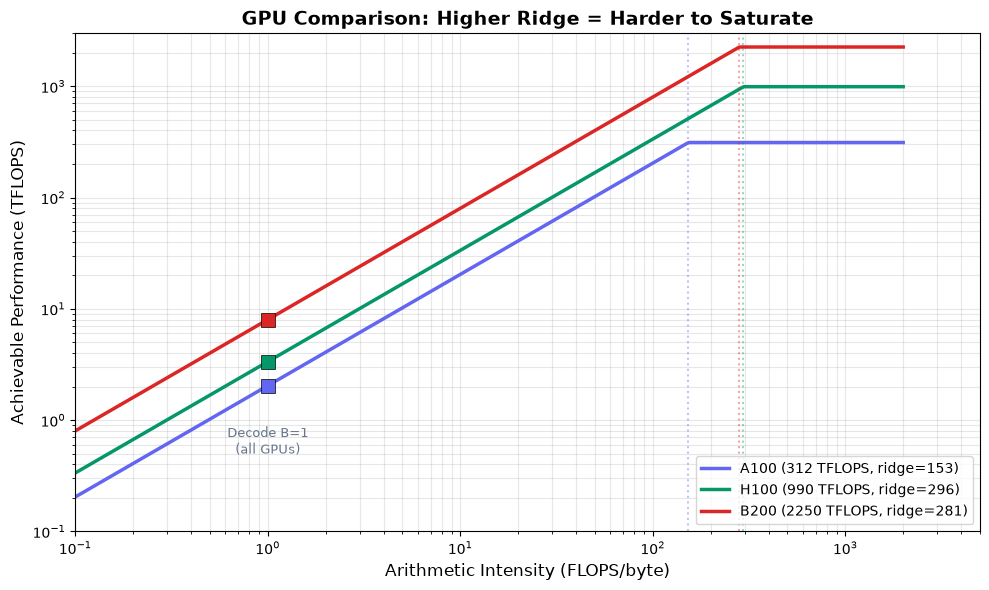

In [8]:
# --- Compare rooflines across GPU generations ---
# Key insight: faster GPUs have HIGHER ridge points, meaning
# you need even MORE batching to become compute-bound.

gpus_to_compare = ['A100', 'H100', 'B200']
gpu_colors = {'A100': '#6366f1', 'H100': '#059669', 'B200': '#dc2626'}

fig, ax = plt.subplots(figsize=(10, 6))

for name in gpus_to_compare:
    spec = GPU_SPECS[name]
    peak = spec['compute_tflops']
    bw = spec['bandwidth_gbs']
    ridge = peak * 1e3 / bw  # FLOPS/byte

    # Compute roofline for this GPU
    roof = np.minimum(ai * bw / 1e3, peak)
    ax.loglog(ai, roof, '-', color=gpu_colors[name], linewidth=2.5,
              label=f'{name} ({peak} TFLOPS, ridge={ridge:.0f})')

    # Plot decode batch=1 operating point on each GPU
    dec_perf = min(decode_ai * bw / 1e3, peak)
    ax.plot(decode_ai, dec_perf, 's', color=gpu_colors[name],
            markersize=10, markeredgecolor='black', markeredgewidth=0.5)

    # Mark ridge point
    ax.axvline(ridge, color=gpu_colors[name], linestyle=':', alpha=0.4)

# Annotate the decode column
ax.annotate('Decode B=1\n(all GPUs)', xy=(decode_ai, 0.5),
            fontsize=9, ha='center', color='#64748b')

ax.set_xlabel('Arithmetic Intensity (FLOPS/byte)', fontsize=12)
ax.set_ylabel('Achievable Performance (TFLOPS)', fontsize=12)
ax.set_title('GPU Comparison: Higher Ridge = Harder to Saturate',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim(0.1, 5000)
ax.set_ylim(0.1, 3000)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## Key Takeaways

1. **Decode is ~153x below the ridge point** on A100. At batch=1, you use <1% of the GPU's compute capacity. The GPU spends almost all its time waiting for memory.

2. **Batching helps** by amortizing weight reads across tokens. You need batch ~153 on A100 to cross the ridge. But KV cache memory limits how large your batch can grow (each sequence's KV cache consumes VRAM).

3. **Better GPUs have HIGHER ridge points.** H100's ridge is ~296 FLOPS/byte vs A100's ~153. This means newer GPUs are *even harder* to saturate with decode workloads.

4. **LLM inference is fundamentally a bandwidth problem.** The roofline proves it: no amount of faster compute helps when you're stuck on the memory-bound slope. The only levers are: batch more tokens, compress the model (quantization), or buy more bandwidth.